# Домашнее задание 10

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor

from pathlib import Path

import joblib

import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
df = pd.read_csv("data/housing_az_sqm_azn.csv")
print(f"Dataset shape: {df.shape}")
print()
print(f"Columns: {df.columns.to_list()}")
print()
print(f"First few rows:")
df.head()

Dataset shape: (240, 5)

Columns: ['PriceAZN', 'Bedrooms', 'Bathrooms', 'Sqm', 'City']

First few rows:


,PriceAZN,Bedrooms,Bathrooms,Sqm,City
0,225000,1,1,87.9,Baku
1,53200,3,2,45.0,Sumqayit
2,224100,3,2,81.2,Baku
3,318500,4,1,120.6,Baku
4,148900,5,1,126.9,Ganja


In [3]:
y = df["PriceAZN"].astype(float)

X = df[["Bedrooms", "Bathrooms", "Sqm", "City"]]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (240, 4)
y shape: (240,)


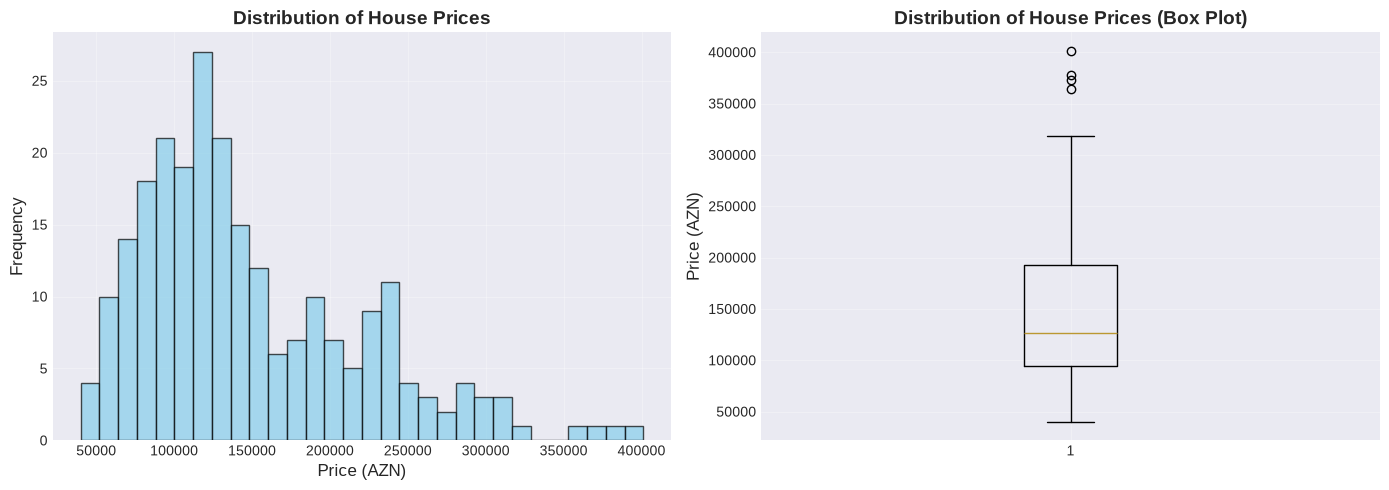

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y, bins=30, color="skyblue", edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of House Prices", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Price (AZN)", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(y)
axes[1].set_title("Distribution of House Prices (Box Plot)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Price (AZN)", fontsize=12)
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

In [5]:
print("Price statistics:")
print(f"Mean: {y.mean():.2f} AZN")
print(f"Median: {y.median():.2f} AZN")
print(f"Std {y.std():.2f} AZN")
print(f"Min: {y.min():.2f} AZN")
print(f"Max: {y.max():.2f} AZN")

Price statistics:
Mean: 147927.08 AZN
Median: 126950.00 AZN
Std 71134.65 AZN
Min: 40000.00 AZN
Max: 401100.00 AZN


In [6]:
numeric_features = ["Bedrooms", "Bathrooms", "Sqm"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_features = ["City"]

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [7]:
xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)

In [8]:
pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", xgb)
])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Train set shape: (192, 4)
Test set shape: (48, 4)


In [10]:
pipe.fit(X_train, y_train);

In [11]:
preds = pipe.predict(X_test)
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
rmse = root_mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("=" * 50)
print("Model Metrics:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")
print("=" * 50)

Model Metrics:
MAE: 13841.93
MSE: 361090724.11
RMSE: 19002.39
R2: 0.91


In [12]:
test_predictions = pd.DataFrame(
    {
        "Bedrooms": [3],
        "Bathrooms": [1],
        "Sqm": [250],
        "City": ["Ganja"],
    }
)
prediction = pipe.predict(test_predictions)[0]
print(f"Predicted price: {prediction:.2f} AZN")

Predicted price: 206693.02 AZN


In [13]:
bundle = {
    "pipeline": pipe,
    "featured_order": ["Bedrooms", "Bathrooms", "Sqm", "City"],
}

model_path = Path("model_az.pkl")

joblib.dump(bundle, model_path);